In [7]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Algorithm/train.csv')
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [8]:
df = df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Survived']]
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1}) # 수치형 데이터로 변환(인코딩)
df = df.dropna() # 결측치(NaN)가 포함된 행을 제거
X = df.drop('Survived', axis=1)
y = df['Survived']

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

In [10]:
from sklearn import tree
model = tree.DecisionTreeClassifier()

In [11]:
model.fit(X_train, y_train)

DecisionTreeClassifier()

In [12]:
y_predict = model.predict(X_test)
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_predict)

0.8212290502793296

In [13]:
from sklearn.metrics import confusion_matrix
pd.DataFrame(
    confusion_matrix(y_test, y_predict),
    columns=['Predicted Not Survival', 'Predicted Survival'],
    index=['True Not Survival', 'True Survival']
)

,Predicted Not Survival,Predicted Survival
True Not Survival,97,15
True Survival,17,50


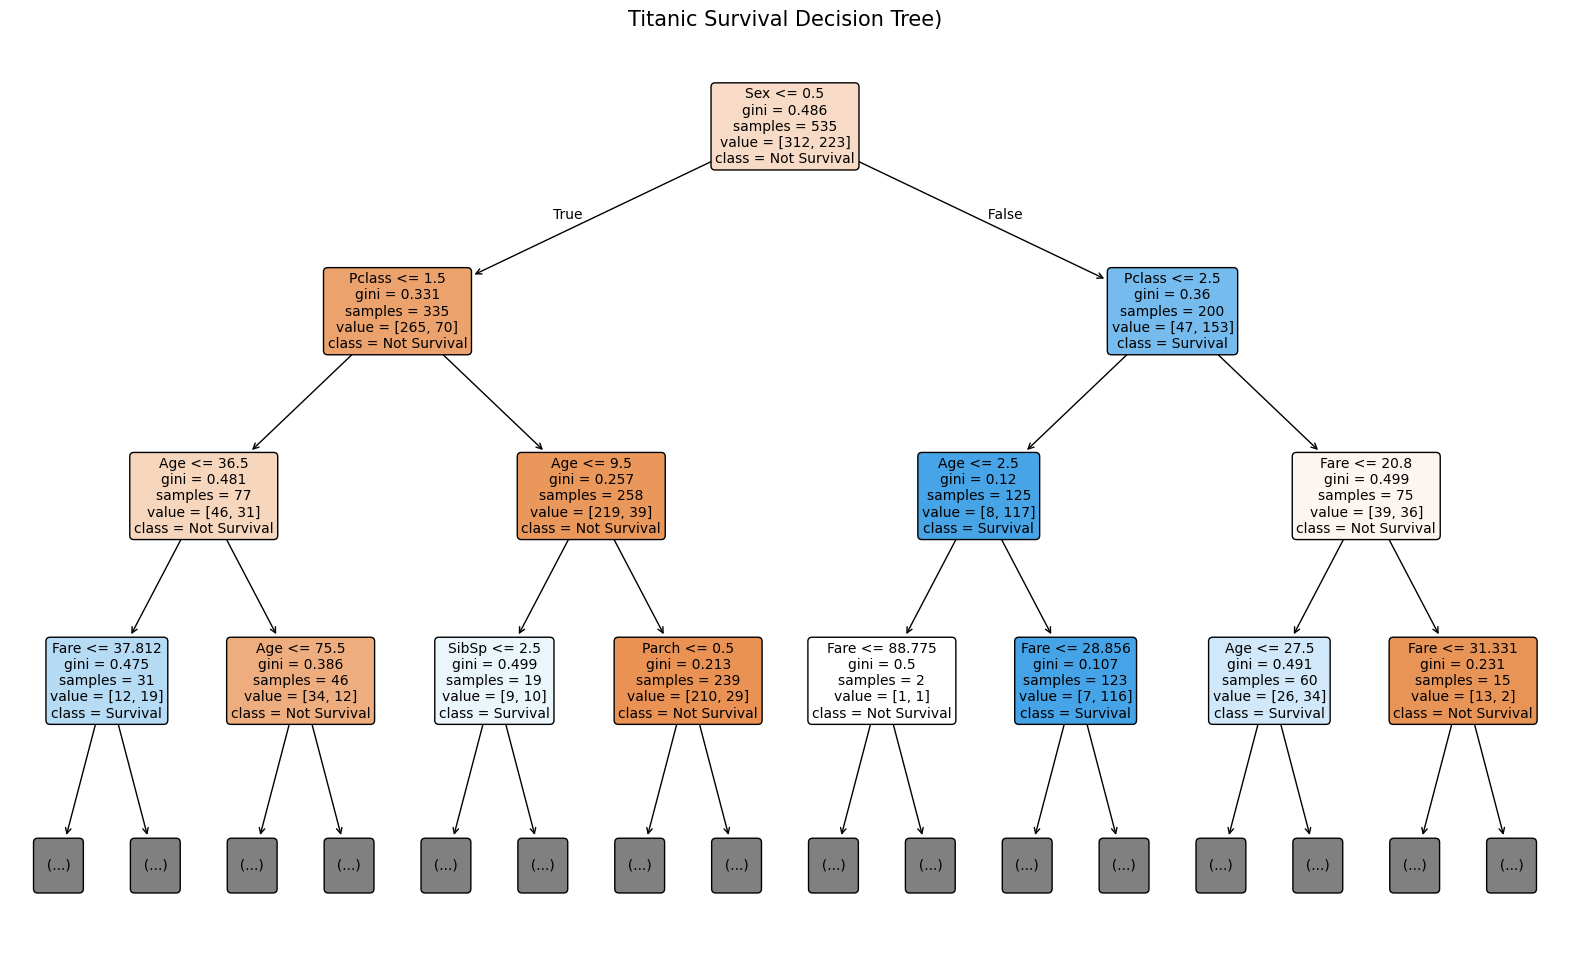

In [16]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 12))

# 2. 결정 트리
plot_tree(model,
          feature_names=X.columns.tolist(),    # 특성 이름 (Pclass, Sex 등)
          class_names=['Not Survival', 'Survival'], # 정답 클래스 이름
          filled=True,                         # 불순도에 따라 색상 채우기
          rounded=True,                        # 박스 모서리 둥글게
          fontsize=10,                         # 글자 크기
          max_depth=3)                         # 너무 복잡하면 보기 힘드니 깊이를 3단계까지만 제한 (선택사항)

plt.title("Titanic Survival Decision Tree)", fontsize=15)
plt.show()